# New Year indicator mask — visual QA

Builds `ny_pre` / `ny_mid` / `ny_post` masks from the wide CSV column dates using a plain `pd.to_datetime` + `.month`/`.day` approach, then cross-checks against `build_ny_indicators_by_date` and prints only the flagged weeks so they can be eyeballed.

**Rule.** Each column date is a Monday (week start). A week is flagged if the 7-day window `[d, d+6]` contains the calendar anchor:

- `ny_pre`  -> week containing **Dec 25**
- `ny_mid`  -> week containing **Jan 1**
- `ny_post` -> week containing **Jan 8**

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'validation' else Path.cwd()
sys.path.insert(0, str(ROOT))

header = pd.read_csv(ROOT / 'data/wide_weekly_scaledPer10k.csv', nrows=0)
dates = pd.to_datetime(header.columns[1:])
print(f'{len(dates)} weekly Mondays: {dates.min().date()} -> {dates.max().date()}')

170 weekly Mondays: 2023-01-02 -> 2026-03-30


In [3]:
dates

DatetimeIndex(['2023-01-02', '2023-01-09', '2023-01-16', '2023-01-23',
               '2023-01-30', '2023-02-06', '2023-02-13', '2023-02-20',
               '2023-02-27', '2023-03-06',
               ...
               '2026-01-26', '2026-02-02', '2026-02-09', '2026-02-16',
               '2026-02-23', '2026-03-02', '2026-03-09', '2026-03-16',
               '2026-03-23', '2026-03-30'],
              dtype='datetime64[ns]', length=170, freq=None)

In [4]:
ends = dates + pd.Timedelta(days=6)
# date before new year
ny_dates = dates[(dates.year != ends.year) | (dates.dayofyear == 1)] # covers all dates containing the first of january (new year)
ny_dates = list(ny_dates)
# date after new year
ny_p1_dates = [dates[0]] # first dataset date is after new year
ny_p1_dates = ny_p1_dates + [date + pd.Timedelta(weeks=1) for date in ny_dates]
# date before new year
ny_p0_dates  = [date - pd.Timedelta(weeks=1) for date in ny_dates]
ny_pm1_dates = [date - pd.Timedelta(weeks=2) for date in ny_dates]
ny_pm2_dates = [date - pd.Timedelta(weeks=3) for date in ny_dates]


print("week after 1/1:\t\t", ny_p1_dates)
print("week containing 1/1:\t", ny_dates)
print("1 week before 1/1:\t", ny_p0_dates)
print("2 week before 1/1:\t", ny_pm1_dates)
print("3 week before 1/1:\t", ny_pm2_dates)

week after 1/1:		 [Timestamp('2023-01-02 00:00:00'), Timestamp('2024-01-08 00:00:00'), Timestamp('2025-01-06 00:00:00'), Timestamp('2026-01-05 00:00:00')]
week containing 1/1:	 [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-12-30 00:00:00'), Timestamp('2025-12-29 00:00:00')]
1 week before 1/1:	 [Timestamp('2023-12-25 00:00:00'), Timestamp('2024-12-23 00:00:00'), Timestamp('2025-12-22 00:00:00')]
2 week before 1/1:	 [Timestamp('2023-12-18 00:00:00'), Timestamp('2024-12-16 00:00:00'), Timestamp('2025-12-15 00:00:00')]
3 week before 1/1:	 [Timestamp('2023-12-11 00:00:00'), Timestamp('2024-12-09 00:00:00'), Timestamp('2025-12-08 00:00:00')]


In [5]:
# overall mask
mask = dates.isin(ny_dates) | dates.isin(ny_p1_dates) | dates.isin(ny_p0_dates)
print("correct (1 orphan post + 3 full turn-of-years x 3 weeks): ", 1+3+3+3)
print("actual: ",mask.sum())
print(mask)

correct (1 orphan post + 3 full turn-of-years x 3 weeks):  10
actual:  10
[ True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False  True  True  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False  True  True  True False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False F

In [6]:
# ny mask
ny_mask = dates.isin(ny_dates) 
print("correct: ", 3)
print("actual: ",ny_mask.sum())
print(ny_mask)

correct:  3
actual:  3
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False  True False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False  True False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
  True False False False Fal

In [7]:
# after mask
after_mask = dates.isin(ny_p1_dates) 
print("correct: ", 1+1+1+1)
print("actual: ",after_mask.sum())
print(after_mask)

correct:  4
actual:  4
[ True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False  True False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False  True False False Fal

In [8]:
# before mask
before_mask = dates.isin(ny_p0_dates) 
print("correct: ", 1+1+1)
print("actual: ",before_mask.sum())
print(before_mask)

correct:  3
actual:  3
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False  True False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False  True
 False False False False Fal

In [9]:
# 2 week before mask
w2_before_mask = dates.isin(ny_pm1_dates) 
print("correct: ", 1+1+1)
print("actual: ",w2_before_mask.sum())
print(w2_before_mask)

correct:  3
actual:  3
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False  True False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False  True False
 False False False False Fal

In [10]:
# 3 week before mask
w3_before_mask = dates.isin(ny_pm2_dates) 
print("correct: ", 1+1+1)
print("actual: ",w3_before_mask.sum())
print(w3_before_mask)

correct:  3
actual:  3
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False  True False False
 False False False False Fal

## Plot — turn-of-year overlay

Rate-per-10k around the Mon-of-Jan-1 week. Each turn-of-year is its own line, aligned so day 0 = the Mon-week containing Jan 1. Vertical dashed lines mark the four indicator weeks (`ny_pm1` -14d, `ny_pre` -7d, `ny_mid` 0d, `ny_post` +7d).

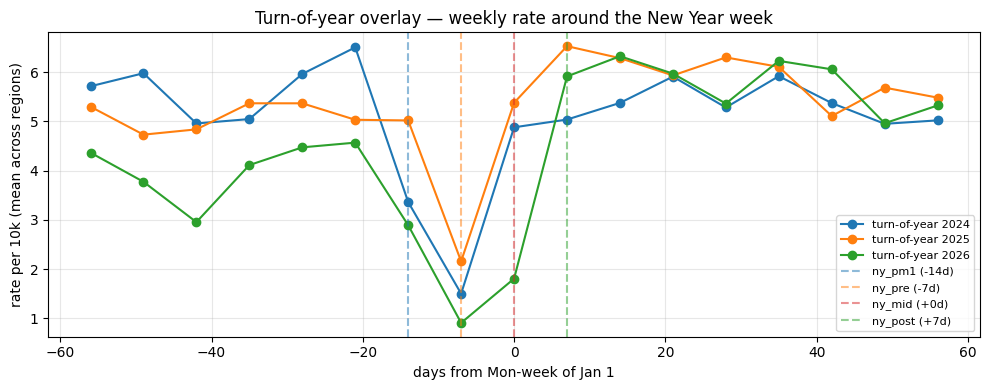

In [11]:
import matplotlib.pyplot as plt

# national-ish weekly rate = mean across regions (per-10k units preserved)
df_full = pd.read_csv(ROOT / 'data/wide_weekly_scaledPer10k.csv')
rate = pd.Series(df_full.drop(columns='Region').mean(axis=0).values, index=dates)

window_weeks = range(-8, 9)  # +/- 8 weeks around the Mon-of-Jan-1

fig, ax = plt.subplots(figsize=(10, 4))

for mid in ny_dates:
    rel_days, vals = [], []
    for w in window_weeks:
        t = mid + pd.Timedelta(weeks=w)
        if t in rate.index:
            rel_days.append(w * 7)
            vals.append(rate.loc[t])
    ax.plot(rel_days, vals, marker='o', label=f'turn-of-year {(mid + pd.Timedelta(days=6)).year}')

for day, lab, col in [(-14, 'ny_pm1', 'C0'),
                      (-7,  'ny_pre', 'C1'),
                      (0,   'ny_mid', 'C3'),
                      (7,   'ny_post', 'C2')]:
    ax.axvline(day, color=col, ls='--', alpha=0.5, label=f'{lab} ({day:+d}d)')

ax.set_xlabel('days from Mon-week of Jan 1')
ax.set_ylabel('rate per 10k (mean across regions)')
ax.set_title('Turn-of-year overlay — weekly rate around the New Year week')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()